# Real-World Case Study: Machine Learning Applications in Options Pricing

The workflow uses three CSV files collected earlier: an option-chain snapshot, a U.S. Treasury curve and the underlying stock price history.
The notebook is intentionally practical. It starts with a clean market snapshot, engineers a compact but meaningful set of features, and then compares machine learning models with a classical Black-Scholes benchmark.

## 1. Imports and setup

In [1]:
# Imports
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch

from scipy.interpolate import interp1d
from scipy.stats import norm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.utils import set_random_seed

In [2]:
# Setup and reproducibility controls
GLOBAL_SEED = 42
TRAIN_SEED = 42
TEST_SEED = 123

os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)

# More deterministic PyTorch behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Stable-Baselines3 seed helper
set_random_seed(GLOBAL_SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 2. Load the raw CSV files

These are the same CSVs exported from the earlier market-data collection workflow.

In [3]:
options_file = "mb_all_options_data12302025 2025-12-30 17-24-55-033746.csv"
rates_file = "mb_US_T_12292025 2025-12-30 17-06-29-282207.csv"
underlying_file = "mb_tickerdf12302025 2025-12-30 17-24-53-423976.csv"

df_options_raw = pd.read_csv(options_file)
df_rates_raw = pd.read_csv(rates_file)
df_underlying_raw = pd.read_csv(underlying_file)

print("Options raw shape:", df_options_raw.shape)
print("Rates raw shape:", df_rates_raw.shape)
print("Underlying raw shape:", df_underlying_raw.shape)

display(df_options_raw.head())
display(df_rates_raw.head())
display(df_underlying_raw.head())

Options raw shape: (2322, 18)
Rates raw shape: (11, 3)
Underlying raw shape: (1255, 8)


,Unnamed: 0,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,OptionType,expirationDate,time_to_expiration
0,0,AAPL260102C00120000,2025-12-29 14:52:51+00:00,120.0,153.88,151.60,154.95,0.0,0.0,1.0,1,3.335939,True,REGULAR,USD,Call,2026-01-02,3
1,1,AAPL260102C00135000,2025-12-08 14:31:30+00:00,135.0,144.95,136.55,139.95,0.0,0.0,NaN,2,2.843753,True,REGULAR,USD,Call,2026-01-02,3
2,2,AAPL260102C00145000,2025-11-19 16:06:45+00:00,145.0,126.05,126.55,130.00,0.0,0.0,NaN,6,2.621097,True,REGULAR,USD,Call,2026-01-02,3
3,3,AAPL260102C00150000,2025-12-29 20:59:30+00:00,150.0,123.83,121.60,124.95,0.0,0.0,2.0,12,2.492191,True,REGULAR,USD,Call,2026-01-02,3
4,4,AAPL260102C00155000,2025-12-29 20:59:30+00:00,155.0,118.90,116.55,120.00,0.0,0.0,4.0,3,2.369145,True,REGULAR,USD,Call,2026-01-02,3


,Unnamed: 0,US_Treasury_Pillar,Yield
0,0,1M,3.69
1,1,3M,3.68
2,2,6M,3.59
3,3,1Y,3.48
4,4,2Y,3.45


,Unnamed: 0,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2020-12-31,130.520487,131.162969,128.223139,129.167389,99116600,0.0,0.0
1,2021-01-04,129.975370,130.062977,123.394829,125.974480,143301900,0.0,0.0
2,2021-01-05,125.468261,128.242606,125.020466,127.531975,97664900,0.0,0.0
3,2021-01-06,124.329352,127.570950,123.024922,123.239082,155088000,0.0,0.0
4,2021-01-07,124.952354,128.135547,124.465627,127.444389,109578200,0.0,0.0


## 3. Define the snapshot date

We use the export date of the option chain as the market snapshot date.

In [4]:
snapshot_date = pd.Timestamp("2025-12-30")
print("Snapshot date:", snapshot_date.date())

Snapshot date: 2025-12-30


## 4. Prepare the underlying data and compute historical volatility

We extract the underlying spot price at the snapshot date and calculate short-horizon historical volatility measures from the underlying price history.

In [5]:
df_underlying = df_underlying_raw.copy()

date_col = df_underlying.columns[0]
df_underlying[date_col] = pd.to_datetime(df_underlying[date_col], errors="coerce")
df_underlying = df_underlying.sort_values(date_col).set_index(date_col)

spot_price = float(df_underlying.loc[:snapshot_date, "Close"].iloc[-1])

df_underlying["log_return"] = np.log(df_underlying["Close"] / df_underlying["Close"].shift(1))

trading_days = 252
df_underlying["hv_30d"] = df_underlying["log_return"].rolling(30).std() * np.sqrt(trading_days)
df_underlying["hv_60d"] = df_underlying["log_return"].rolling(60).std() * np.sqrt(trading_days)

hv_30d = float(df_underlying.loc[:snapshot_date, "hv_30d"].iloc[-1])
hv_60d = float(df_underlying.loc[:snapshot_date, "hv_60d"].iloc[-1])

print("Spot price S0:", round(spot_price, 6))
print("30d Historical Vol:", round(hv_30d, 6))
print("60d Historical Vol:", round(hv_60d, 6))

Spot price S0: 273.079987
30d Historical Vol: 0.141088
60d Historical Vol: 0.178446


## 5. Prepare the Treasury curve and build a maturity-rate mapping

The Treasury pillars are converted into year fractions, and a linear interpolator is used to map the risk-free rate to each option maturity.

In [6]:
df_rates = df_rates_raw.copy()

def pillar_to_years(pillar: str) -> float:
    pillar = str(pillar).strip().upper()
    if pillar.endswith("M"):
        return float(pillar[:-1]) / 12.0
    elif pillar.endswith("Y"):
        return float(pillar[:-1])
    else:
        raise ValueError(f"Unsupported pillar format: {pillar}")

df_rates["maturity_years"] = df_rates["US_Treasury_Pillar"].apply(pillar_to_years)
df_rates["rate_decimal"] = df_rates["Yield"] / 100.0
df_rates = df_rates.sort_values("maturity_years")

rate_interp = interp1d(
    df_rates["maturity_years"].values,
    df_rates["rate_decimal"].values,
    kind="linear",
    fill_value="extrapolate"
)

display(df_rates)

,Unnamed: 0,US_Treasury_Pillar,Yield,maturity_years,rate_decimal
0,0,1M,3.69,0.083333,0.0369
1,1,3M,3.68,0.250000,0.0368
2,2,6M,3.59,0.500000,0.0359
3,3,1Y,3.48,1.000000,0.0348
4,4,2Y,3.45,2.000000,0.0345
5,5,3Y,3.51,3.000000,0.0351
6,6,5Y,3.67,5.000000,0.0367
7,7,7Y,3.88,7.000000,0.0388
8,8,10Y,4.12,10.000000,0.0412
9,9,20Y,4.75,20.000000,0.0475


## 6. Black-Scholes pricing helper

For single-stock listed options, Black-Scholes is used here as a **benchmark**, not as a perfect theoretical price.

In [7]:
def mb_bs_price(option_type, S, K, T, r, sigma, q=0.0):
    """
    Compact Black-Scholes-Merton closed-form pricing function using symbolic notation.
    Compute the Black-Scholes price of a European option with a continuous dividend yield.

    Parameters
    ----------
    option_type : str, 'Call' or 'Put'
    S : float, spot price of the underlying asset
    K : float, strike price
    T : float, time to maturity (in years)
    r : float, risk-free interest rate
    sigma : float, volatility of the underlying asset
    q : float, continuous dividend yield, default is 0.0

    Returns
    -------
    float, Black-Scholes price of the option
    """
    if T <= 0:
        if option_type == "Call":
            return max(S - K, 0.0)
        else:
            return max(K - S, 0.0)

    sigma = max(float(sigma), 1e-8)

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "Call":
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

## 7. Prepare the options snapshot

We treat the exported option-chain CSV as the market snapshot dataset.  
The target for the first machine learning case study will be the **market mid price**.

#### 7-A. Build and clean the market snapshot

In [8]:
df_options = df_options_raw.copy()

df_options["lastTradeDate"] = pd.to_datetime(
    df_options["lastTradeDate"], errors="coerce", utc=True
)
df_options["expirationDate"] = pd.to_datetime(
    df_options["expirationDate"], errors="coerce"
)

df_options["time_to_maturity"] = (
    df_options["expirationDate"] - snapshot_date
).dt.days / 365.0

df_options["mid_price"] = (df_options["bid"] + df_options["ask"]) / 2.0
df_options["option_type_flag"] = np.where(
    df_options["OptionType"].str.upper() == "CALL", 1, 0
)

df_options["underlying_price"] = spot_price
df_options["hv_30d"] = hv_30d
df_options["hv_60d"] = hv_60d
df_options["interest_rate"] = rate_interp(df_options["time_to_maturity"].values)

df_options = df_options[
    (df_options["time_to_maturity"] > 0.02) &
    (df_options["strike"] > 0) &
    (df_options["bid"].notna()) &
    (df_options["ask"].notna()) &
    (df_options["mid_price"].notna()) &
    (df_options["mid_price"] > 0) &
    (df_options["impliedVolatility"].notna()) &
    (df_options["impliedVolatility"] > 0.01) &
    (df_options["impliedVolatility"] < 5.0)
].copy()

df_options = df_options[df_options["ask"] >= df_options["bid"]].copy()

print("Cleaned options snapshot shape:", df_options.shape)
display(df_options.head())

Cleaned options snapshot shape: (2172, 25)


,Unnamed: 0,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,OptionType,expirationDate,time_to_expiration,time_to_maturity,mid_price,option_type_flag,underlying_price,hv_30d,hv_60d,interest_rate
114,114,AAPL260109C00145000,2025-12-26 19:24:20+00:00,145.0,130.02,126.45,130.15,0.000000,0.000000,1.0,1,1.605471,True,REGULAR,USD,Call,2026-01-09,10,0.027397,128.300,1,273.079987,0.141088,0.178446,0.036934
115,115,AAPL260109C00150000,2025-12-22 18:38:38+00:00,150.0,121.40,121.55,125.15,0.000000,0.000000,1.0,5,1.570315,True,REGULAR,USD,Call,2026-01-09,10,0.027397,123.350,1,273.079987,0.141088,0.178446,0.036934
116,116,AAPL260109C00155000,2025-12-19 20:28:51+00:00,155.0,116.07,116.45,120.15,0.000000,0.000000,5.0,5,1.451175,True,REGULAR,USD,Call,2026-01-09,10,0.027397,118.300,1,273.079987,0.141088,0.178446,0.036934
117,117,AAPL260109C00160000,2025-12-17 15:20:42+00:00,160.0,115.37,111.55,115.15,0.000000,0.000000,NaN,1,1.416995,True,REGULAR,USD,Call,2026-01-09,10,0.027397,113.350,1,273.079987,0.141088,0.178446,0.036934
118,118,AAPL260109C00170000,2025-12-30 20:18:40+00:00,170.0,103.44,102.15,104.50,-7.959999,-7.145421,3.0,1,1.254887,True,REGULAR,USD,Call,2026-01-09,10,0.027397,103.325,1,273.079987,0.141088,0.178446,0.036934


#### 7-B. Engineer the derived pricing features

In [9]:
df_options["intrinsic_value"] = np.where(
    df_options["option_type_flag"] == 1,
    np.maximum(df_options["underlying_price"] - df_options["strike"], 0.0),
    np.maximum(df_options["strike"] - df_options["underlying_price"], 0.0)
)

df_options["time_value"] = np.maximum(
    df_options["mid_price"] - df_options["intrinsic_value"], 0.0
)

df_options["moneyness"] = df_options["strike"] / df_options["underlying_price"]
df_options["log_moneyness"] = np.log(
    df_options["underlying_price"] / df_options["strike"]
)
df_options["sqrt_T"] = np.sqrt(df_options["time_to_maturity"])

display(
    df_options[
        [
            "strike",
            "time_to_maturity",
            "sqrt_T",
            "moneyness",
            "log_moneyness",
            "intrinsic_value",
            "time_value",
        ]
    ].head()
)

,strike,time_to_maturity,sqrt_T,moneyness,log_moneyness,intrinsic_value,time_value
114,145.0,0.027397,0.165521,0.530980,0.633031,128.079987,0.220013
115,150.0,0.027397,0.165521,0.549290,0.599129,123.079987,0.270013
116,155.0,0.027397,0.165521,0.567599,0.566340,118.079987,0.220013
117,160.0,0.027397,0.165521,0.585909,0.534591,113.079987,0.270013
118,170.0,0.027397,0.165521,0.622528,0.473966,103.079987,0.245013


#### 7-C. Compute the Black-Scholes benchmark feature

In [10]:
df_options["bs_price_from_obs_iv"] = df_options.apply(
    lambda row: mb_bs_price(
        option_type=row["OptionType"],
        S=row["underlying_price"],
        K=row["strike"],
        T=row["time_to_maturity"],
        r=row["interest_rate"],
        sigma=row["impliedVolatility"],
        q=0.0
    ),
    axis=1
)

display(
    df_options[
        [
            "OptionType",
            "strike",
            "mid_price",
            "impliedVolatility",
            "bs_price_from_obs_iv",
        ]
    ].head()
)

,OptionType,strike,mid_price,impliedVolatility,bs_price_from_obs_iv
114,Call,145.0,128.300,1.605471,128.375534
115,Call,150.0,123.350,1.570315,123.417942
116,Call,155.0,118.300,1.451175,118.386442
117,Call,160.0,113.350,1.416995,113.428982
118,Call,170.0,103.325,1.254887,103.421435


## 8. Save the chapter option-pricing dataset

In [11]:
option_price_data = df_options[
    [
        "OptionType",
        "option_type_flag",
        "strike",
        "time_to_maturity",
        "sqrt_T",
        "underlying_price",
        "interest_rate",
        "impliedVolatility",
        "hv_30d",
        "hv_60d",
        "moneyness",
        "log_moneyness",
        "intrinsic_value",
        "time_value",
        "bs_price_from_obs_iv",
        "mid_price"
    ]
].copy()

option_price_data = option_price_data.rename(
    columns={
        "impliedVolatility": "implied_volatility",
        "mid_price": "market_option_price"
    }
)

option_price_data.to_csv("option_price_data.csv", index=False)

print("Saved: option_price_data.csv")
display(option_price_data.head())

Saved: option_price_data.csv


,OptionType,option_type_flag,strike,time_to_maturity,sqrt_T,underlying_price,interest_rate,implied_volatility,hv_30d,hv_60d,moneyness,log_moneyness,intrinsic_value,time_value,bs_price_from_obs_iv,market_option_price
114,Call,1,145.0,0.027397,0.165521,273.079987,0.036934,1.605471,0.141088,0.178446,0.530980,0.633031,128.079987,0.220013,128.375534,128.300
115,Call,1,150.0,0.027397,0.165521,273.079987,0.036934,1.570315,0.141088,0.178446,0.549290,0.599129,123.079987,0.270013,123.417942,123.350
116,Call,1,155.0,0.027397,0.165521,273.079987,0.036934,1.451175,0.141088,0.178446,0.567599,0.566340,118.079987,0.220013,118.386442,118.300
117,Call,1,160.0,0.027397,0.165521,273.079987,0.036934,1.416995,0.141088,0.178446,0.585909,0.534591,113.079987,0.270013,113.428982,113.350
118,Call,1,170.0,0.027397,0.165521,273.079987,0.036934,1.254887,0.141088,0.178446,0.622528,0.473966,103.079987,0.245013,103.421435,103.325


## 9. Sanity checks for option pricing

In [12]:
option_price_data.describe()

,option_type_flag,strike,time_to_maturity,sqrt_T,underlying_price,interest_rate,implied_volatility,hv_30d,hv_60d,moneyness,log_moneyness,intrinsic_value,time_value,bs_price_from_obs_iv,market_option_price
count,2172.000000,2172.000000,2172.000000,2172.000000,2172.000000,2172.000000,2172.000000,2.172000e+03,2172.000000,2172.000000,2172.000000,2172.000000,2172.000000,2172.000000,2172.000000
mean,0.537293,236.167127,0.774944,0.776495,273.079987,0.035775,0.470627,1.410876e-01,0.178446,0.864828,0.322349,39.955790,5.529517,45.612105,45.483347
std,0.498722,113.504924,0.703495,0.414823,0.000000,0.000952,0.430306,2.776197e-17,0.000000,0.415647,0.717272,63.243797,8.700655,63.702213,63.370221
min,0.000000,5.000000,0.027397,0.165521,273.079987,0.034511,0.117196,1.410876e-01,0.178446,0.018310,-0.700154,0.000000,0.000000,0.002645,0.005000
25%,0.000000,155.000000,0.142466,0.377446,273.079987,0.034787,0.250465,1.410876e-01,0.178446,0.567599,-0.126808,0.000000,0.220000,0.635179,0.655000
50%,1.000000,235.000000,0.545205,0.738380,273.079987,0.035801,0.326881,1.410876e-01,0.178446,0.860554,0.150179,0.000000,1.727493,11.883308,11.937500
75%,1.000000,310.000000,1.043836,1.021683,273.079987,0.036865,0.531407,1.410876e-01,0.178446,1.135199,0.566340,63.079987,7.176247,70.790965,70.650000
max,1.000000,550.000000,2.213699,1.487850,273.079987,0.036934,4.875004,1.410876e-01,0.178446,2.014062,4.000327,276.920013,77.079987,270.632451,276.975000


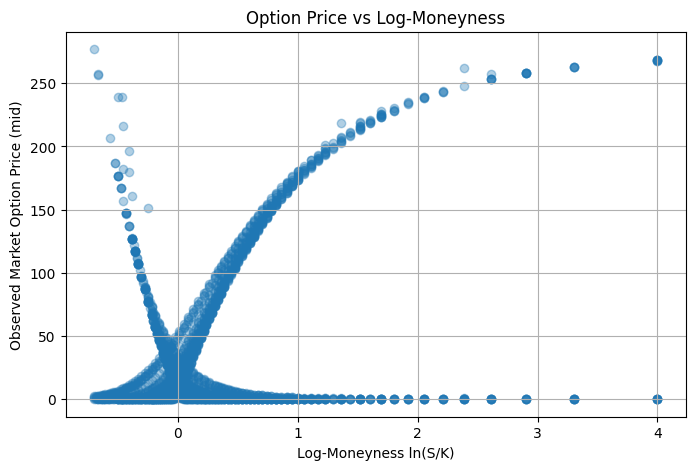

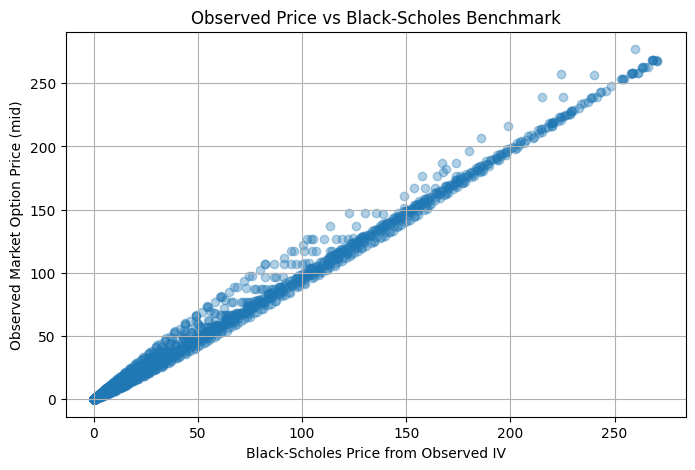

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(option_price_data["log_moneyness"], option_price_data["market_option_price"], alpha=0.35)
plt.xlabel("Log-Moneyness ln(S/K)")
plt.ylabel("Observed Market Option Price (mid)")
plt.title("Option Price vs Log-Moneyness")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(option_price_data["bs_price_from_obs_iv"], option_price_data["market_option_price"], alpha=0.35)
plt.xlabel("Black-Scholes Price from Observed IV")
plt.ylabel("Observed Market Option Price (mid)")
plt.title("Observed Price vs Black-Scholes Benchmark")
plt.grid(True)
plt.show()

# Part A - Machine Learning for Option Pricing

## 10. Build the machine learning dataset for option pricing

In [14]:
pricing_df = pd.read_csv("option_price_data.csv")

pricing_feature_cols = [
    "option_type_flag",
    "log_moneyness",
    "time_to_maturity",
    "sqrt_T",
    "interest_rate",
    "implied_volatility",
    "hv_30d",
    "hv_60d",
    "intrinsic_value"
]

pricing_target_col = "market_option_price"

X_price = pricing_df[pricing_feature_cols].copy()
y_price = pricing_df[pricing_target_col].copy()

X_price_train, X_price_test, y_price_train, y_price_test = train_test_split(
    X_price, y_price, test_size=0.20, random_state=42
)

# aligned benchmark split
_, X_price_test_full, _, _ = train_test_split(
    pricing_df, y_price, test_size=0.20, random_state=42
)

print("Pricing train shape:", X_price_train.shape)
print("Pricing test shape:", X_price_test.shape)

Pricing train shape: (1737, 9)
Pricing test shape: (435, 9)


## 11. Regression evaluation helper

In [15]:
def evaluate_regression(y_true, y_pred, model_name="Model"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

## 12. Fit baseline and machine learning models for option pricing

In [16]:
pricing_results = []

baseline_mean_pred = np.full_like(y_price_test, y_price_train.mean(), dtype=float)
pricing_results.append(evaluate_regression(y_price_test, baseline_mean_pred, "Baseline Mean Price"))

bs_benchmark_pred = X_price_test_full["bs_price_from_obs_iv"].values
pricing_results.append(evaluate_regression(y_price_test, bs_benchmark_pred, "Black-Scholes Benchmark"))

linear_price_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linear_price_model.fit(X_price_train, y_price_train)
linear_price_pred = linear_price_model.predict(X_price_test)
pricing_results.append(evaluate_regression(y_price_test, linear_price_pred, "Linear Regression"))

rf_price_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_price_model.fit(X_price_train, y_price_train)
rf_price_pred = rf_price_model.predict(X_price_test)
pricing_results.append(evaluate_regression(y_price_test, rf_price_pred, "Random Forest"))

gbr_price_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr_price_model.fit(X_price_train, y_price_train)
gbr_price_pred = gbr_price_model.predict(X_price_test)
pricing_results.append(evaluate_regression(y_price_test, gbr_price_pred, "Gradient Boosting"))

pricing_results_df = pd.DataFrame(pricing_results).sort_values("RMSE")
display(pricing_results_df)

,Model,MSE,RMSE,MAE,R2
4,Gradient Boosting,4.003650,2.000912,1.341025,0.999003
3,Random Forest,8.901194,2.983487,1.052182,0.997784
1,Black-Scholes Benchmark,24.744289,4.974363,2.506203,0.993839
2,Linear Regression,41.304741,6.426876,4.209019,0.989716
0,Baseline Mean Price,4023.031999,63.427376,51.403670,-0.001622


In [17]:
# Save option pricing results table
pricing_results_df.to_csv("option_pricing_results.csv", index=False)
print("Saved: option_pricing_results.csv")

Saved: option_pricing_results.csv


## 13. Plot actual versus predicted values for option pricing

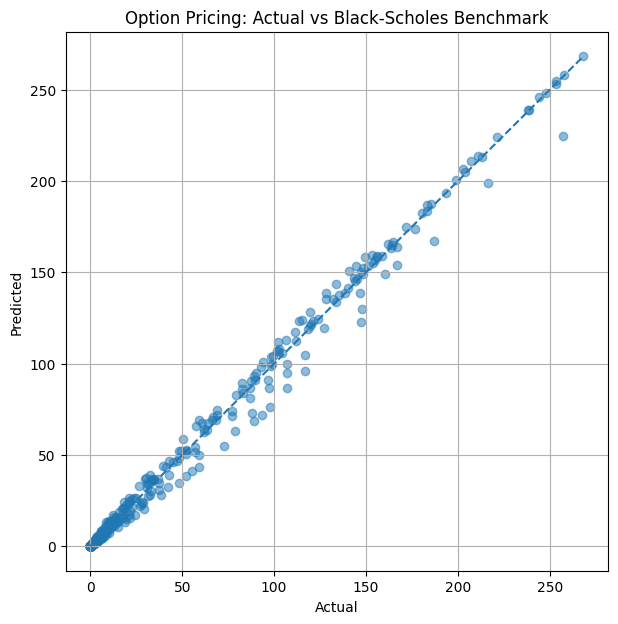

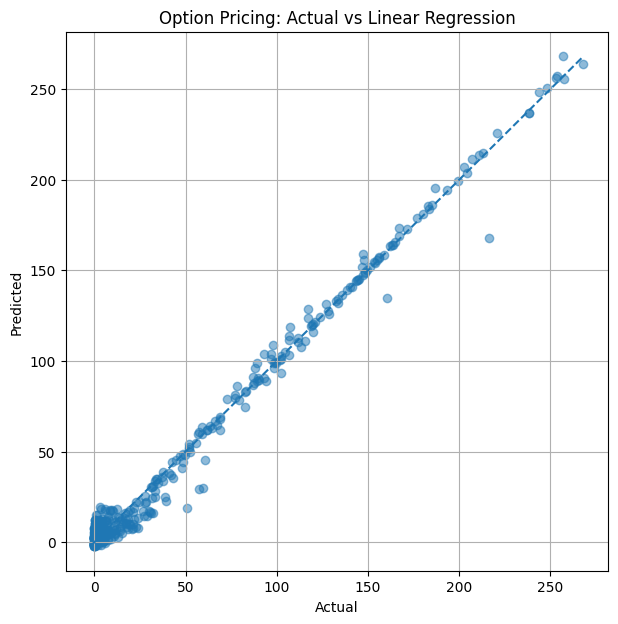

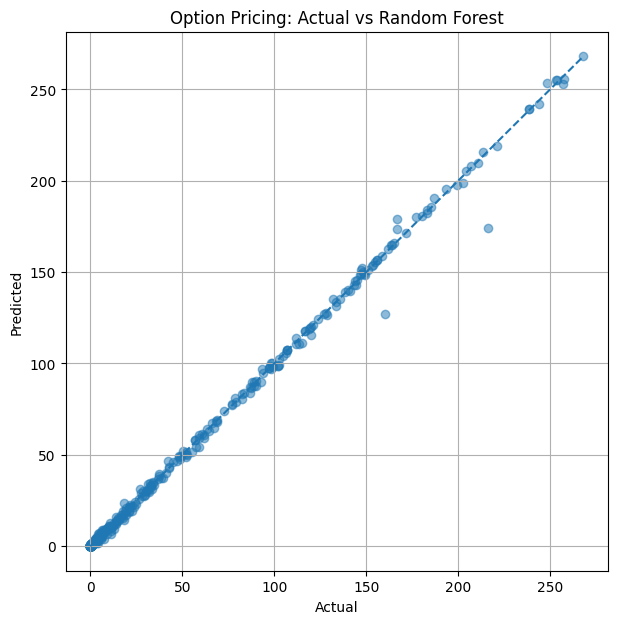

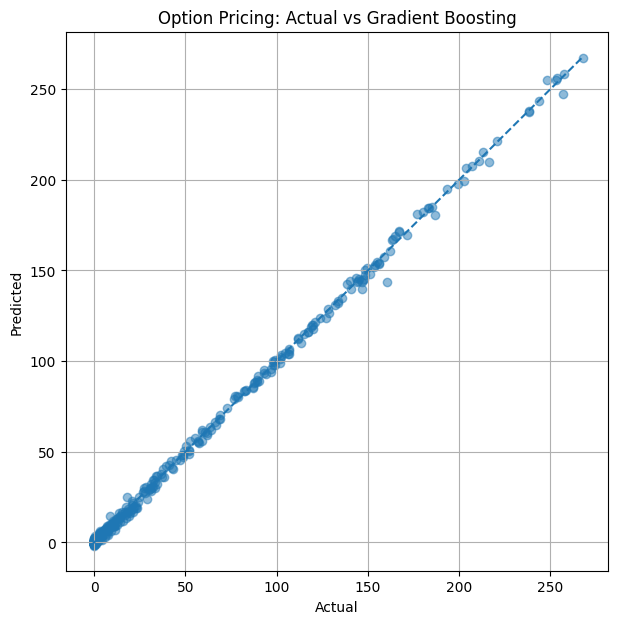

In [18]:
def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, alpha=0.5)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_actual_vs_pred(y_price_test, bs_benchmark_pred, "Option Pricing: Actual vs Black-Scholes Benchmark")
plot_actual_vs_pred(y_price_test, linear_price_pred, "Option Pricing: Actual vs Linear Regression")
plot_actual_vs_pred(y_price_test, rf_price_pred, "Option Pricing: Actual vs Random Forest")
plot_actual_vs_pred(y_price_test, gbr_price_pred, "Option Pricing: Actual vs Gradient Boosting")

In [19]:
# Sample actual versus predicted option prices
pricing_compare_df = pd.DataFrame({
    "Actual_Price": y_price_test.values,
    "Predicted_Price_RF": rf_price_pred
}).reset_index(drop=True)

display(pricing_compare_df.head(15))

,Actual_Price,Predicted_Price_RF
0,96.950,97.668572
1,34.175,34.900964
2,2.715,3.024843
3,176.875,180.095210
4,0.130,0.120013
5,86.975,83.708236
6,0.930,1.351733
7,4.300,3.992795
8,113.450,110.606464
9,7.550,8.440692


## 14. Feature importance for option pricing

,Feature,Importance
8,intrinsic_value,0.981871
1,log_moneyness,0.005633
5,implied_volatility,0.004827
4,interest_rate,0.003148
2,time_to_maturity,0.002196
3,sqrt_T,0.002102
0,option_type_flag,0.000221
6,hv_30d,0.000000
7,hv_60d,0.000000


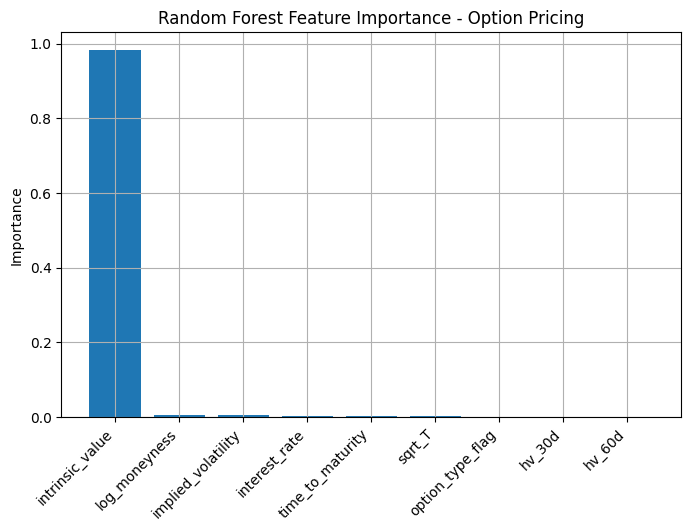

In [20]:
rf_importance = pd.DataFrame({
    "Feature": pricing_feature_cols,
    "Importance": rf_price_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(rf_importance)

plt.figure(figsize=(8, 5))
plt.bar(rf_importance["Feature"], rf_importance["Importance"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance - Option Pricing")
plt.grid(True)
plt.show()

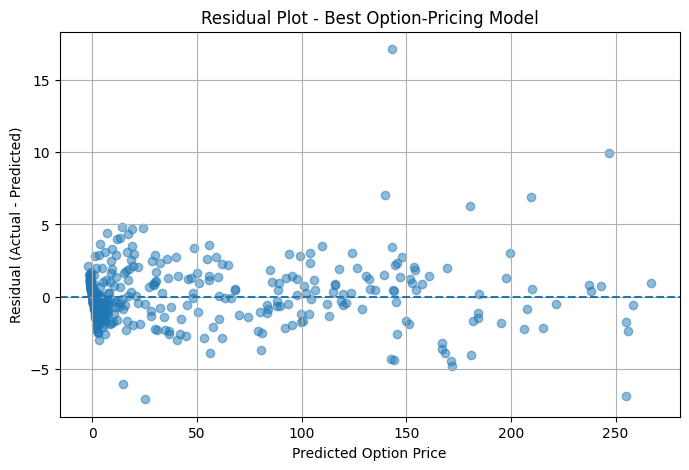

In [21]:
# Residual plot for the best option-pricing model
pricing_residuals = y_price_test.values - gbr_price_pred

plt.figure(figsize=(8, 5))
plt.scatter(gbr_price_pred, pricing_residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Option Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot - Best Option-Pricing Model")
plt.grid(True)
plt.show()

# Part B - Machine Learning for Implied Volatility

In this second case study, we use the same cleaned market snapshot but shift the target from **option price** to **implied volatility**.

## 15. Save the chapter implied-volatility dataset

In [22]:
option_iv_data = df_options[
    [
        "OptionType",
        "option_type_flag",
        "strike",
        "time_to_maturity",
        "sqrt_T",
        "underlying_price",
        "interest_rate",
        "hv_30d",
        "hv_60d",
        "moneyness",
        "log_moneyness",
        "impliedVolatility"
    ]
].copy()

option_iv_data = option_iv_data.rename(columns={"impliedVolatility": "implied_volatility"})
option_iv_data.to_csv("option_iv_data.csv", index=False)

print("Saved: option_iv_data.csv")
display(option_iv_data.head())

Saved: option_iv_data.csv


,OptionType,option_type_flag,strike,time_to_maturity,sqrt_T,underlying_price,interest_rate,hv_30d,hv_60d,moneyness,log_moneyness,implied_volatility
114,Call,1,145.0,0.027397,0.165521,273.079987,0.036934,0.141088,0.178446,0.530980,0.633031,1.605471
115,Call,1,150.0,0.027397,0.165521,273.079987,0.036934,0.141088,0.178446,0.549290,0.599129,1.570315
116,Call,1,155.0,0.027397,0.165521,273.079987,0.036934,0.141088,0.178446,0.567599,0.566340,1.451175
117,Call,1,160.0,0.027397,0.165521,273.079987,0.036934,0.141088,0.178446,0.585909,0.534591,1.416995
118,Call,1,170.0,0.027397,0.165521,273.079987,0.036934,0.141088,0.178446,0.622528,0.473966,1.254887


## 16. Build the machine learning dataset for implied volatility

In [23]:
iv_df = pd.read_csv("option_iv_data.csv")

iv_feature_cols = [
    "option_type_flag",
    "log_moneyness",
    "time_to_maturity",
    "sqrt_T",
    "interest_rate",
    "hv_30d"
]

iv_target_col = "implied_volatility"

X_iv = iv_df[iv_feature_cols].copy()
y_iv = iv_df[iv_target_col].copy()

X_iv_train, X_iv_test, y_iv_train, y_iv_test = train_test_split(
    X_iv, y_iv, test_size=0.20, random_state=42
)

print("IV train shape:", X_iv_train.shape)
print("IV test shape:", X_iv_test.shape)

IV train shape: (1737, 6)
IV test shape: (435, 6)


## 17. Fit baseline and machine learning models for implied volatility

In [24]:
iv_results = []

baseline_iv_pred = np.full_like(y_iv_test, y_iv_train.mean(), dtype=float)
iv_results.append(evaluate_regression(y_iv_test, baseline_iv_pred, "Baseline Mean IV"))

linear_iv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
linear_iv_model.fit(X_iv_train, y_iv_train)
linear_iv_pred = linear_iv_model.predict(X_iv_test)
iv_results.append(evaluate_regression(y_iv_test, linear_iv_pred, "Linear Regression"))

rf_iv_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_iv_model.fit(X_iv_train, y_iv_train)
rf_iv_pred = rf_iv_model.predict(X_iv_test)
iv_results.append(evaluate_regression(y_iv_test, rf_iv_pred, "Random Forest"))

gbr_iv_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr_iv_model.fit(X_iv_train, y_iv_train)
gbr_iv_pred = gbr_iv_model.predict(X_iv_test)
iv_results.append(evaluate_regression(y_iv_test, gbr_iv_pred, "Gradient Boosting"))

iv_results_df = pd.DataFrame(iv_results).sort_values("RMSE")
display(iv_results_df)

,Model,MSE,RMSE,MAE,R2
2,Random Forest,0.006005,0.077491,0.030691,0.973402
3,Gradient Boosting,0.009414,0.097025,0.048093,0.958302
1,Linear Regression,0.097741,0.312636,0.169795,0.567067
0,Baseline Mean IV,0.225989,0.475383,0.265881,-0.000992


In [25]:
# Save implied volatility results table
iv_results_df.to_csv("iv_results.csv", index=False)
print("Saved: iv_results.csv")

Saved: iv_results.csv


## 18. Plot actual versus predicted values for implied volatility

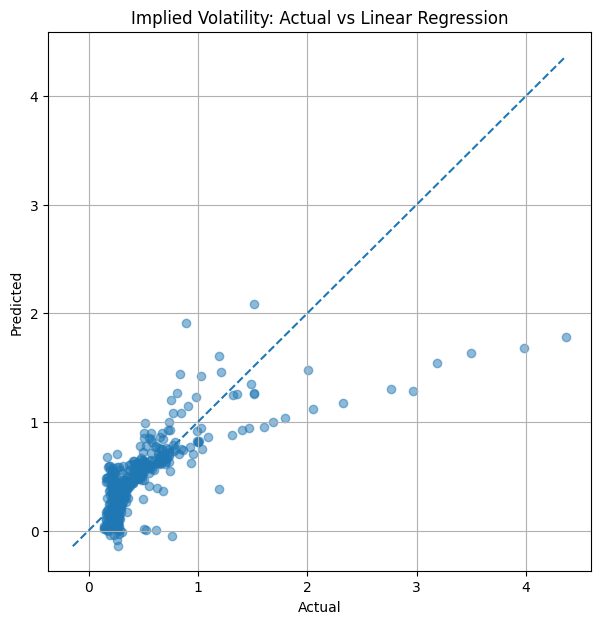

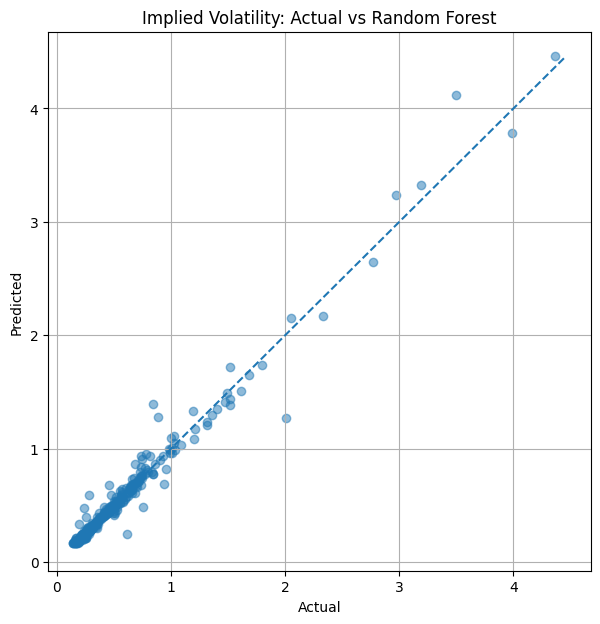

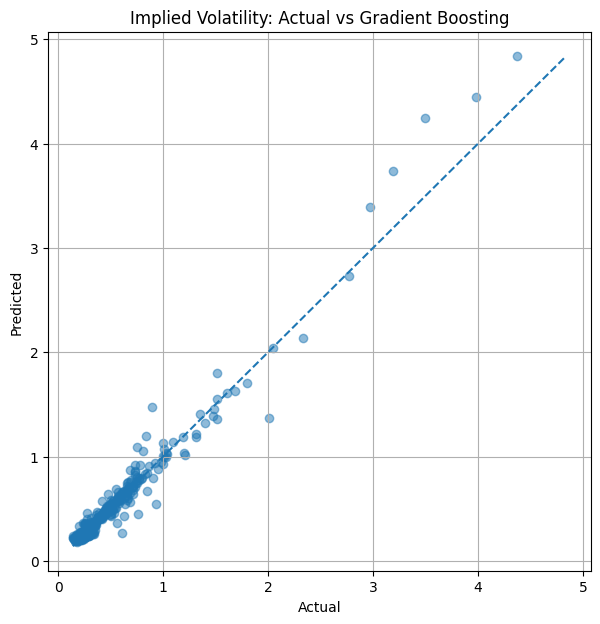

In [26]:
plot_actual_vs_pred(y_iv_test, linear_iv_pred, "Implied Volatility: Actual vs Linear Regression")
plot_actual_vs_pred(y_iv_test, rf_iv_pred, "Implied Volatility: Actual vs Random Forest")
plot_actual_vs_pred(y_iv_test, gbr_iv_pred, "Implied Volatility: Actual vs Gradient Boosting")

In [27]:
# Sample actual versus predicted implied volatilities
iv_compare_df = pd.DataFrame({
    "Actual_IV": y_iv_test.values,
    "Predicted_IV_RF": rf_iv_pred
}).reset_index(drop=True)

display(iv_compare_df.head(15))

,Actual_IV,Predicted_IV_RF
0,0.198800,0.176309
1,0.428839,0.434516
2,0.306525,0.311036
3,0.524541,0.456461
4,0.455572,0.465201
5,0.681156,0.701913
6,0.303108,0.304643
7,0.314185,0.321304
8,0.429953,0.427969
9,0.205391,0.213587


## 19. Feature importance for implied volatility

,Feature,Importance
1,log_moneyness,0.656465
4,interest_rate,0.111479
3,sqrt_T,0.096785
2,time_to_maturity,0.093505
0,option_type_flag,0.041766
5,hv_30d,0.000000


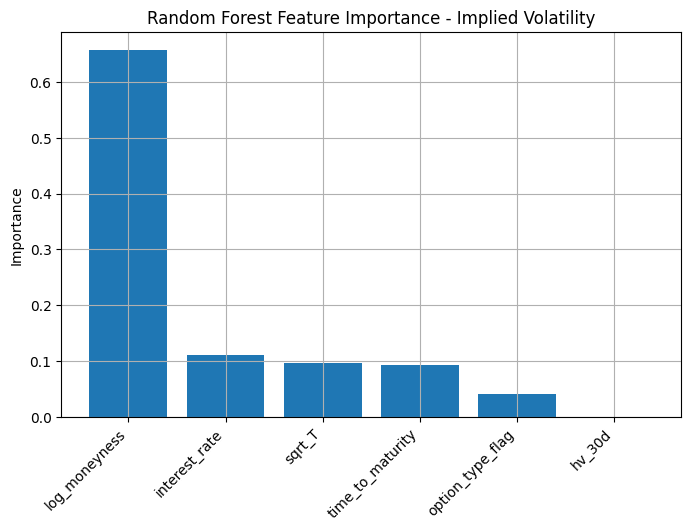

In [28]:
rf_iv_importance = pd.DataFrame({
    "Feature": iv_feature_cols,
    "Importance": rf_iv_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(rf_iv_importance)

plt.figure(figsize=(8, 5))
plt.bar(rf_iv_importance["Feature"], rf_iv_importance["Importance"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance - Implied Volatility")
plt.grid(True)
plt.show()

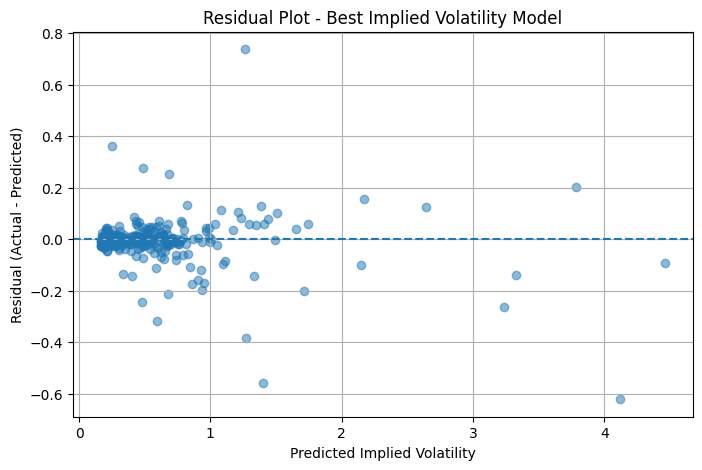

In [29]:
# Residual plot for the best implied volatility model
iv_residuals = y_iv_test.values - rf_iv_pred

plt.figure(figsize=(8, 5))
plt.scatter(rf_iv_pred, iv_residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Implied Volatility")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot - Best Implied Volatility Model")
plt.grid(True)
plt.show()

## 20. Comparison summary between the Option Pricing Results and the Implied Volatility Results

In [30]:
print("Option Pricing Results")
display(pricing_results_df)

print("Implied Volatility Results")
display(iv_results_df)

Option Pricing Results


,Model,MSE,RMSE,MAE,R2
4,Gradient Boosting,4.003650,2.000912,1.341025,0.999003
3,Random Forest,8.901194,2.983487,1.052182,0.997784
1,Black-Scholes Benchmark,24.744289,4.974363,2.506203,0.993839
2,Linear Regression,41.304741,6.426876,4.209019,0.989716
0,Baseline Mean Price,4023.031999,63.427376,51.403670,-0.001622


Implied Volatility Results


,Model,MSE,RMSE,MAE,R2
2,Random Forest,0.006005,0.077491,0.030691,0.973402
3,Gradient Boosting,0.009414,0.097025,0.048093,0.958302
1,Linear Regression,0.097741,0.312636,0.169795,0.567067
0,Baseline Mean IV,0.225989,0.475383,0.265881,-0.000992


# Part C - Reinforcement Learning for Dynamic Hedging

## 21. Reinforcement Learning for Dynamic Hedging with Market-Based Input

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 753  |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 1024 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 706           |
|    iterations           | 2             |
|    time_elapsed         | 2             |
|    total_timesteps      | 2048          |
| train/                  |               |
|    approx_kl            | 0.00039763015 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.42         |
|    explained_variance   | 0.00119       |
|    learning_rate        | 0.0001        |
|    loss                 | 1e+03         |
|    n_updates            | 10            |
|    policy_gradient_loss | -0.000456     |
|    std                  | 0.999         |
|    value_loss          

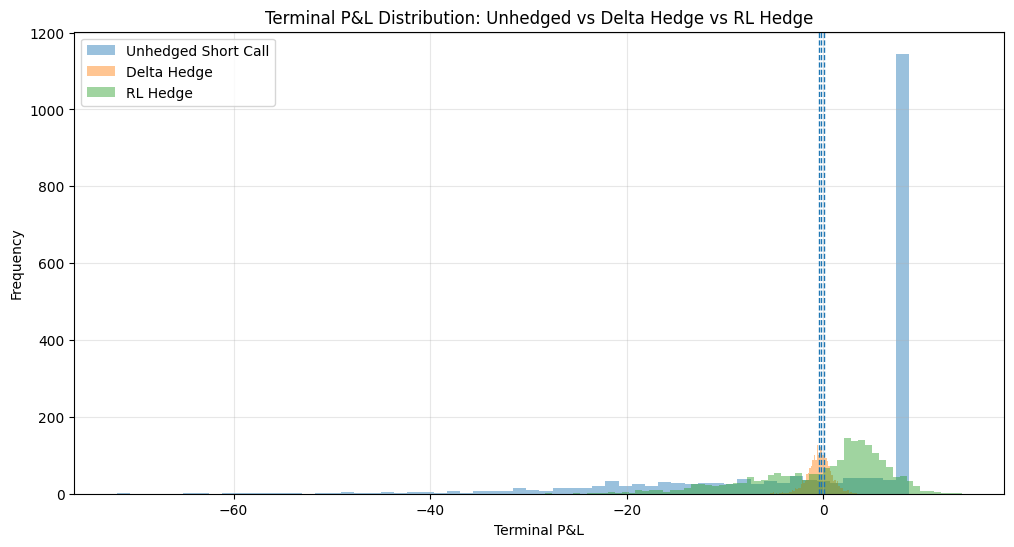

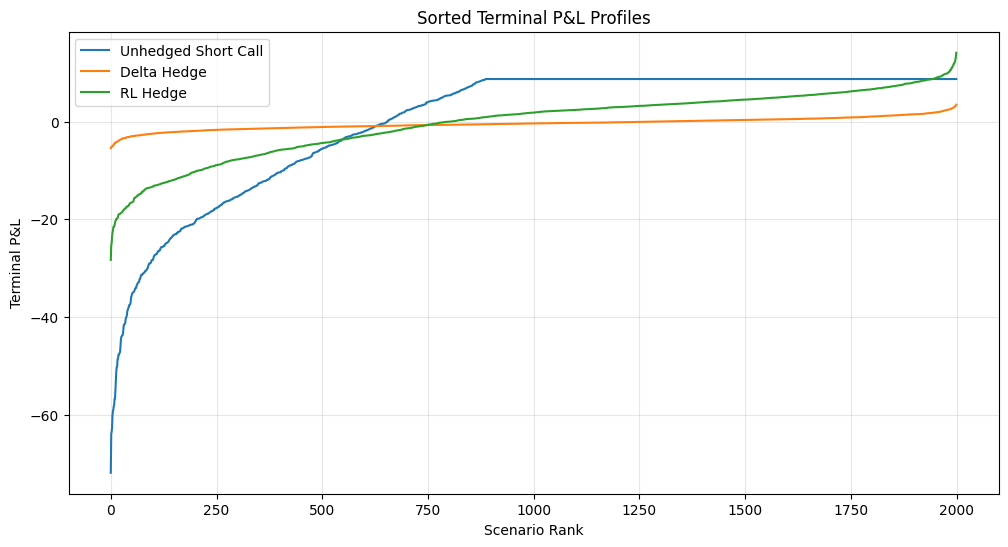

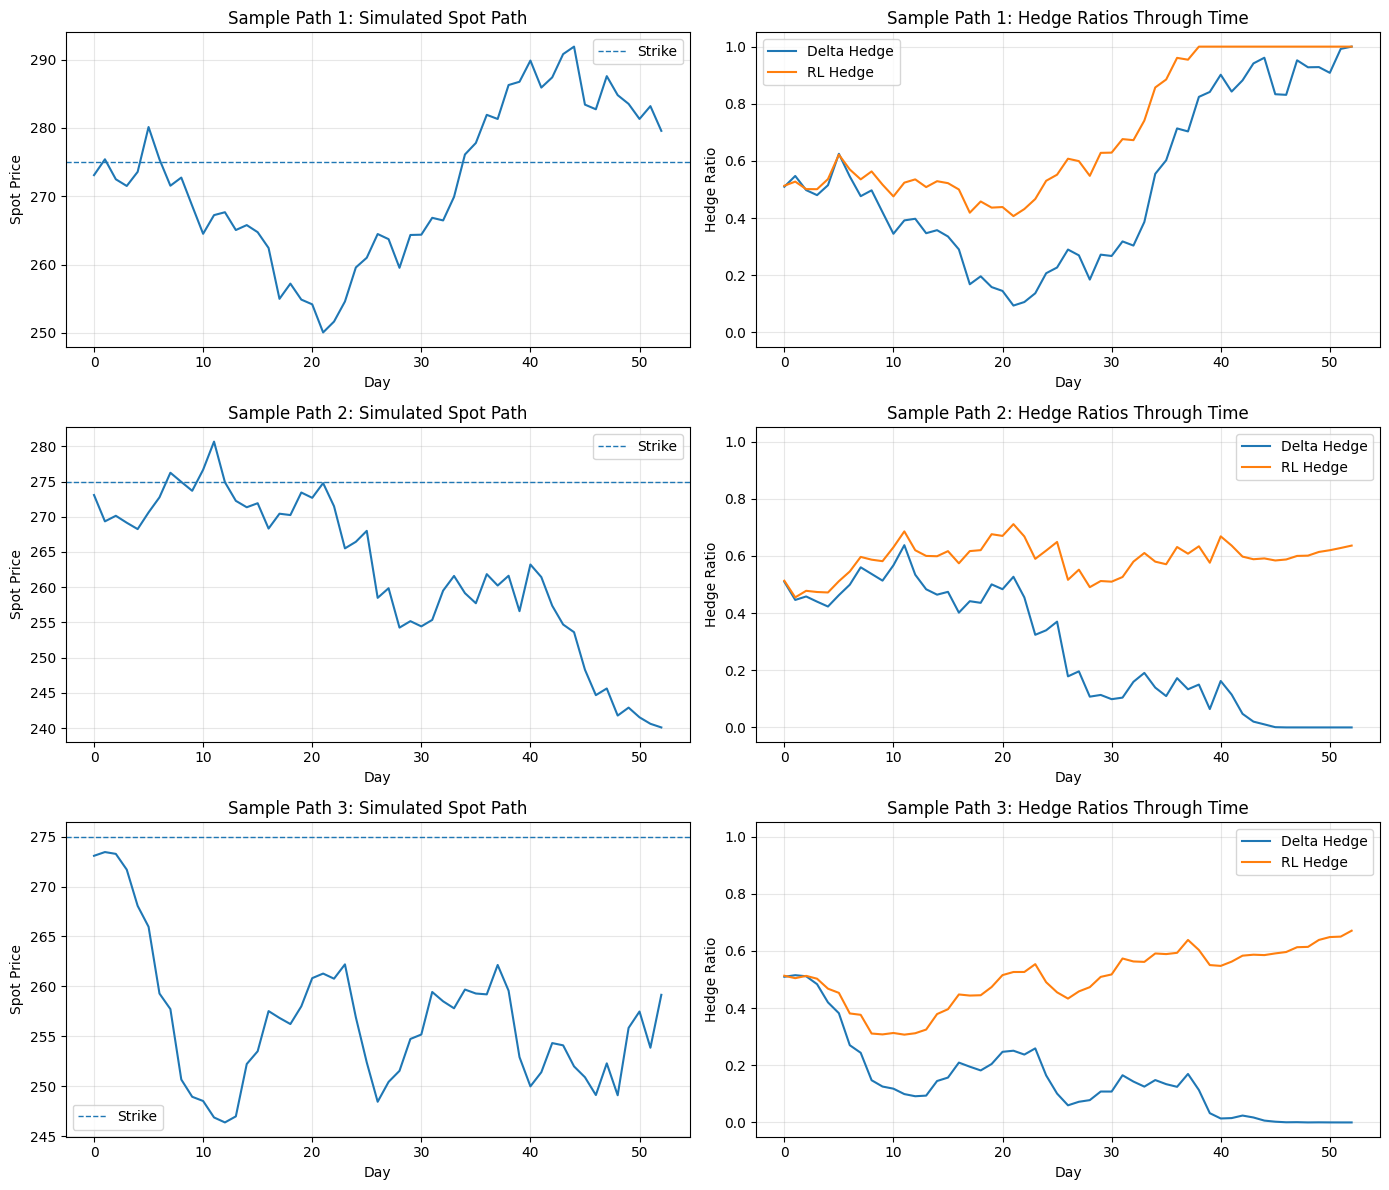

In [31]:
# ============================================================
# RL Dynamic Hedging with Market-Based Inputs
#
# Source files used earlier in the book:
# - mb_all_options_data12302025
# - mb_tickerdf12302025
# - mb_US_T_12292025
#
# Selected contract from the market snapshot:
# AAPL 2026-02-20 275 Call
# ============================================================

# ============================================================
# 1. Contract and experiment inputs
# ============================================================

# Extracted from the market snapshot / market files
S0 = 273.08
K = 275.00
T_days = 52
T = T_days / 365.0
r = 0.03686
sigma_iv = 0.23359
option_mid = 8.75

# Hedging / simulation setup
n_steps = T_days                  # daily rebalancing
dt = 1 / 365
n_train_paths = 4000
n_test_paths = 2000
transaction_cost_bps = 5          # 5 bps per dollar traded
mu = 0.00                         # simple neutral drift
seed_train = TRAIN_SEED
seed_test = TEST_SEED


# ============================================================
# 2. Black-Scholes helper functions
# ============================================================

def mb_bs_call_price(S, K, T, r, sigma):
    """
    Black-Scholes European call price.
    Supports scalar or numpy array S.
    """
    S = np.asarray(S, dtype=float)
    S = np.maximum(S, 1e-12)

    if T <= 0:
        return np.maximum(S - K, 0.0)

    sigma = max(float(sigma), 1e-12)
    sqrtT = np.sqrt(T)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT

    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def mb_bs_call_delta(S, K, T, r, sigma):
    """
    Black-Scholes European call delta.
    Supports scalar or numpy array S.
    """
    S = np.asarray(S, dtype=float)
    S = np.maximum(S, 1e-12)

    if T <= 0:
        return np.where(S > K, 1.0, 0.0)

    sigma = max(float(sigma), 1e-12)
    sqrtT = np.sqrt(T)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    return norm.cdf(d1)


# ============================================================
# 3. Spot path simulation
# ============================================================

def simulate_gbm_paths(S0, mu, sigma, dt, n_steps, n_paths, seed=42):
    """
    Simulate GBM paths.
    Returns array of shape (n_paths, n_steps + 1).
    """
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n_paths, n_steps))

    paths = np.zeros((n_paths, n_steps + 1), dtype=float)
    paths[:, 0] = S0

    for t in range(1, n_steps + 1):
        paths[:, t] = paths[:, t - 1] * np.exp(
            (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, t - 1]
        )

    return paths


def simulate_one_gbm_path(S0, mu, sigma, dt, n_steps, seed=123):
    """
    Simulate one GBM path.
    """
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(n_steps)

    path = np.zeros(n_steps + 1, dtype=float)
    path[0] = S0

    for t in range(1, n_steps + 1):
        path[t] = path[t - 1] * np.exp(
            (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[t - 1]
        )

    return path


# ============================================================
# 4. Benchmarks
# ============================================================

def run_unhedged_short_call(paths, K, r, sigma, dt, option_premium=None):
    """
    P&L of a short call held to maturity with no hedge.
    """
    n_steps = paths.shape[1] - 1
    T0 = n_steps * dt

    if option_premium is None:
        premium = mb_bs_call_price(paths[:, 0], K, T0, r, sigma)
    else:
        premium = np.full(paths.shape[0], option_premium, dtype=float)

    payoff = np.maximum(paths[:, -1] - K, 0.0)
    pnl = premium - payoff
    return pnl


def run_delta_hedge(paths, K, r, sigma, dt, transaction_cost_bps, option_premium=None):
    """
    Correct discrete delta hedge using cash + stock inventory framework.
    """
    n_paths = paths.shape[0]
    n_steps = paths.shape[1] - 1
    T0 = n_steps * dt

    if option_premium is None:
        cash = mb_bs_call_price(paths[:, 0], K, T0, r, sigma).astype(float)
    else:
        cash = np.full(n_paths, option_premium, dtype=float)

    hedge_pos = np.zeros(n_paths, dtype=float)

    for t in range(n_steps):
        tau_t = (n_steps - t) * dt
        S_t = paths[:, t]

        target_delta = mb_bs_call_delta(S_t, K, tau_t, r, sigma)

        trade = target_delta - hedge_pos
        tc = np.abs(trade) * S_t * (transaction_cost_bps / 10000.0)

        # Rebalance hedge
        cash -= trade * S_t
        cash -= tc
        hedge_pos = target_delta

    # Liquidate hedge at maturity
    S_T = paths[:, -1]
    close_tc = np.abs(hedge_pos) * S_T * (transaction_cost_bps / 10000.0)
    cash += hedge_pos * S_T
    cash -= close_tc

    # Pay short call payoff
    payoff = np.maximum(S_T - K, 0.0)
    pnl = cash - payoff

    return pnl


# ============================================================
# 5. RL hedging environment
# ============================================================

class HedgingEnv(gym.Env):
    """
    RL environment for short-1-call dynamic hedging.

    Action:
        Continuous target hedge ratio in [0, 1]

    State:
        [spot_norm, moneyness, tau, bs_delta, current_hedge, recent_return]
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        S0,
        K,
        r,
        sigma,
        option_premium,
        n_steps,
        dt,
        transaction_cost_bps,
        mu=0.0,
        seed=42
    ):
        super().__init__()

        self.S0 = float(S0)
        self.K = float(K)
        self.r = float(r)
        self.sigma = float(sigma)
        self.option_premium = float(option_premium)
        self.n_steps = int(n_steps)
        self.dt = float(dt)
        self.transaction_cost_bps = float(transaction_cost_bps)
        self.mu = float(mu)

        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.action_space = spaces.Box(
            low=np.array([0.0], dtype=np.float32),
            high=np.array([1.0], dtype=np.float32),
            dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0, 0.0, 0.0, -1.0], dtype=np.float32),
            high=np.array([10.0, 10.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32
        )

        self.path = None
        self.t = None
        self.hedge_pos = None
        self.cash = None

    def _simulate_one_path(self):
        Z = self.rng.standard_normal(self.n_steps)
        path = np.zeros(self.n_steps + 1, dtype=float)
        path[0] = self.S0

        for t in range(1, self.n_steps + 1):
            path[t] = path[t - 1] * np.exp(
                (self.mu - 0.5 * self.sigma**2) * self.dt
                + self.sigma * np.sqrt(self.dt) * Z[t - 1]
            )
        return path

    def _get_state(self):
        S_t = self.path[self.t]
        tau_t = max((self.n_steps - self.t) * self.dt, 0.0)

        if tau_t > 0:
            delta_t = float(mb_bs_call_delta(S_t, self.K, tau_t, self.r, self.sigma))
        else:
            delta_t = 1.0 if S_t > self.K else 0.0

        if self.t == 0:
            recent_ret = 0.0
        else:
            recent_ret = self.path[self.t] / self.path[self.t - 1] - 1.0

        state = np.array([
            S_t / self.S0,
            S_t / self.K,
            tau_t / (self.n_steps * self.dt),
            delta_t,
            self.hedge_pos,
            recent_ret
        ], dtype=np.float32)

        return state

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
    
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        else:
            self.rng = np.random.default_rng(self.seed)
    
        self.path = self._simulate_one_path()
    
        self.t = 0
        self.hedge_pos = 0.0
        self.cash = self.option_premium
    
        return self._get_state(), {}
    
    def step(self, action):
        target_hedge = float(np.clip(action[0], 0.0, 1.0))

        S_t = self.path[self.t]
        S_next = self.path[self.t + 1]

        tau_t = (self.n_steps - self.t) * self.dt
        tau_next = max((self.n_steps - (self.t + 1)) * self.dt, 0.0)

        option_value_t = float(mb_bs_call_price(S_t, self.K, tau_t, self.r, self.sigma))
        option_value_next = float(mb_bs_call_price(S_next, self.K, tau_next, self.r, self.sigma))

        # Rebalance hedge
        trade = target_hedge - self.hedge_pos
        tc = abs(trade) * S_t * (self.transaction_cost_bps / 10000.0)

        self.cash -= trade * S_t
        self.cash -= tc
        self.hedge_pos = target_hedge

        # Mark-to-market portfolio
        portfolio_t = self.cash + self.hedge_pos * S_t - option_value_t
        portfolio_next = self.cash + self.hedge_pos * S_next - option_value_next

        step_pnl = portfolio_next - portfolio_t

        # Penalize unstable hedge outcomes and trading costs
        reward = -(step_pnl ** 2) - 0.1 * tc

        self.t += 1
        terminated = self.t == self.n_steps
        truncated = False
        info = {}

        if terminated:
            S_T = self.path[self.t]

            # Liquidate hedge
            close_tc = abs(self.hedge_pos) * S_T * (self.transaction_cost_bps / 10000.0)
            self.cash += self.hedge_pos * S_T
            self.cash -= close_tc
            self.hedge_pos = 0.0

            # Short call payoff
            payoff = max(S_T - self.K, 0.0)
            self.cash -= payoff

            final_pnl = self.cash
            info["final_pnl"] = final_pnl

            # Terminal penalty
            reward += -(final_pnl ** 2)

        return self._get_state(), reward, terminated, truncated, info


# ============================================================
# 6. Train PPO agent
# ============================================================

def make_env():
    return HedgingEnv(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma_iv,
        option_premium=option_mid,
        n_steps=n_steps,
        dt=dt,
        transaction_cost_bps=transaction_cost_bps,
        mu=mu,
        seed=seed_train
    )

vec_env = DummyVecEnv([make_env])
vec_env.seed(seed_train)

model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    verbose=1,
    learning_rate=1e-4,
    n_steps=1024,
    batch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.001,
    seed=seed_train
)

model.learn(total_timesteps=150000)


# ============================================================
# 7. Evaluate RL hedge
# ============================================================

def evaluate_rl_agent(model, n_eval_episodes=1000, seed=999):
    env = HedgingEnv(
        S0=S0,
        K=K,
        r=r,
        sigma=sigma_iv,
        option_premium=option_mid,
        n_steps=n_steps,
        dt=dt,
        transaction_cost_bps=transaction_cost_bps,
        mu=mu,
        seed=seed
    )

    final_pnls = []
    
    for i in range(n_eval_episodes):
        obs, _ = env.reset(seed=seed + i)
        done = False
    
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
    
        final_pnls.append(info["final_pnl"])
    
    return np.array(final_pnls)

# ============================================================
# 8. Generate test paths and benchmark results
# ============================================================

test_paths = simulate_gbm_paths(
    S0=S0,
    mu=mu,
    sigma=sigma_iv,
    dt=dt,
    n_steps=n_steps,
    n_paths=n_test_paths,
    seed=seed_test
)

pnl_unhedged = run_unhedged_short_call(
    paths=test_paths,
    K=K,
    r=r,
    sigma=sigma_iv,
    dt=dt,
    option_premium=option_mid
)

pnl_delta = run_delta_hedge(
    paths=test_paths,
    K=K,
    r=r,
    sigma=sigma_iv,
    dt=dt,
    transaction_cost_bps=transaction_cost_bps,
    option_premium=option_mid
)

pnl_rl = evaluate_rl_agent(
    model=model,
    n_eval_episodes=n_test_paths,
    seed=seed_test
)


# ============================================================
# 9. Summary statistics
# ============================================================

def summarize_results(name, pnl):
    return {
        "Strategy": name,
        "Mean P&L": np.mean(pnl),
        "Std P&L": np.std(pnl),
        "Median P&L": np.median(pnl),
        "1% Tail": np.percentile(pnl, 1),
        "5% Tail": np.percentile(pnl, 5),
        "Min P&L": np.min(pnl),
        "Max P&L": np.max(pnl)
    }

results = pd.DataFrame([
    summarize_results("Unhedged Short Call", pnl_unhedged),
    summarize_results("Delta Hedge", pnl_delta),
    summarize_results("RL Hedge", pnl_rl)
])

print(results)


# ============================================================
# 10. Plot terminal P&L distributions
# ============================================================

plt.figure(figsize=(12, 6))
plt.hist(pnl_unhedged, bins=60, alpha=0.45, label="Unhedged Short Call")
plt.hist(pnl_delta, bins=60, alpha=0.45, label="Delta Hedge")
plt.hist(pnl_rl, bins=60, alpha=0.45, label="RL Hedge")
plt.axvline(np.mean(pnl_unhedged), linestyle="--", linewidth=1)
plt.axvline(np.mean(pnl_delta), linestyle="--", linewidth=1)
plt.axvline(np.mean(pnl_rl), linestyle="--", linewidth=1)
plt.title("Terminal P&L Distribution: Unhedged vs Delta Hedge vs RL Hedge")
plt.xlabel("Terminal P&L")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# 11. Plot sorted terminal P&L
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(np.sort(pnl_unhedged), label="Unhedged Short Call")
plt.plot(np.sort(pnl_delta), label="Delta Hedge")
plt.plot(np.sort(pnl_rl), label="RL Hedge")
plt.title("Sorted Terminal P&L Profiles")
plt.xlabel("Scenario Rank")
plt.ylabel("Terminal P&L")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# 12. Diagnostic path plots: delta hedge vs RL hedge
# ============================================================

def get_delta_hedge_path(path, K, r, sigma, dt):
    """
    Return the delta hedge ratio through time for one path.
    """
    n_steps = len(path) - 1
    deltas = []

    for t in range(n_steps + 1):
        tau = max((n_steps - t) * dt, 0.0)
        if tau > 0:
            d = float(mb_bs_call_delta(path[t], K, tau, r, sigma))
        else:
            d = 1.0 if path[t] > K else 0.0
        deltas.append(d)

    return np.array(deltas)


def get_rl_hedge_path(model, path, K, r, sigma, dt):
    """
    Return the RL hedge ratio through time for one path.
    """
    n_steps = len(path) - 1
    hedge_pos = 0.0
    rl_actions = []

    for t in range(n_steps + 1):
        S_t = path[t]
        tau = max((n_steps - t) * dt, 0.0)

        if tau > 0:
            delta_t = float(mb_bs_call_delta(S_t, K, tau, r, sigma))
        else:
            delta_t = 1.0 if S_t > K else 0.0

        if t == 0:
            recent_ret = 0.0
        else:
            recent_ret = path[t] / path[t - 1] - 1.0

        state = np.array([
            S_t / S0,
            S_t / K,
            tau / (n_steps * dt),
            delta_t,
            hedge_pos,
            recent_ret
        ], dtype=np.float32)

        action, _ = model.predict(state, deterministic=True)
        hedge_pos = float(np.clip(action[0], 0.0, 1.0))
        rl_actions.append(hedge_pos)

    return np.array(rl_actions)


def plot_sample_paths(model, n_sample_paths=3, base_seed=500):
    """
    Plot up to 3 sample spot paths and corresponding hedge ratios.
    """
    fig, axes = plt.subplots(n_sample_paths, 2, figsize=(14, 4 * n_sample_paths))

    if n_sample_paths == 1:
        axes = np.array([axes])

    for i in range(n_sample_paths):
        path = simulate_one_gbm_path(
            S0=S0,
            mu=mu,
            sigma=sigma_iv,
            dt=dt,
            n_steps=n_steps,
            seed=base_seed + i
        )

        delta_path = get_delta_hedge_path(path, K, r, sigma_iv, dt)
        rl_path = get_rl_hedge_path(model, path, K, r, sigma_iv, dt)

        tgrid = np.arange(n_steps + 1)

        # Spot path
        axes[i, 0].plot(tgrid, path)
        axes[i, 0].axhline(K, linestyle="--", linewidth=1, label="Strike")
        axes[i, 0].set_title(f"Sample Path {i+1}: Simulated Spot Path")
        axes[i, 0].set_xlabel("Day")
        axes[i, 0].set_ylabel("Spot Price")
        axes[i, 0].grid(True, alpha=0.3)
        axes[i, 0].legend()

        # Hedge ratios
        axes[i, 1].plot(tgrid, delta_path, label="Delta Hedge")
        axes[i, 1].plot(tgrid, rl_path, label="RL Hedge")
        axes[i, 1].set_title(f"Sample Path {i+1}: Hedge Ratios Through Time")
        axes[i, 1].set_xlabel("Day")
        axes[i, 1].set_ylabel("Hedge Ratio")
        axes[i, 1].set_ylim(-0.05, 1.05)
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].legend()

    plt.tight_layout()
    plt.show()


# Plot up to 3 sample paths
plot_sample_paths(model, n_sample_paths=3, base_seed=500)

# Part D - Reinforcement Learning for Portfolio Optimization

## 22. Portfolio Allocation with AAPL Stock Example

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1275 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 1024 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1117        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.005131222 |
|    clip_fraction        | 0.00928     |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.26       |
|    explained_variance   | -11         |
|    learning_rate        | 0.0001      |
|    loss                 | 0.00657     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00469    |
|    std                  | 0.999       |
|    value_loss           | 0.0716      |
-----------------

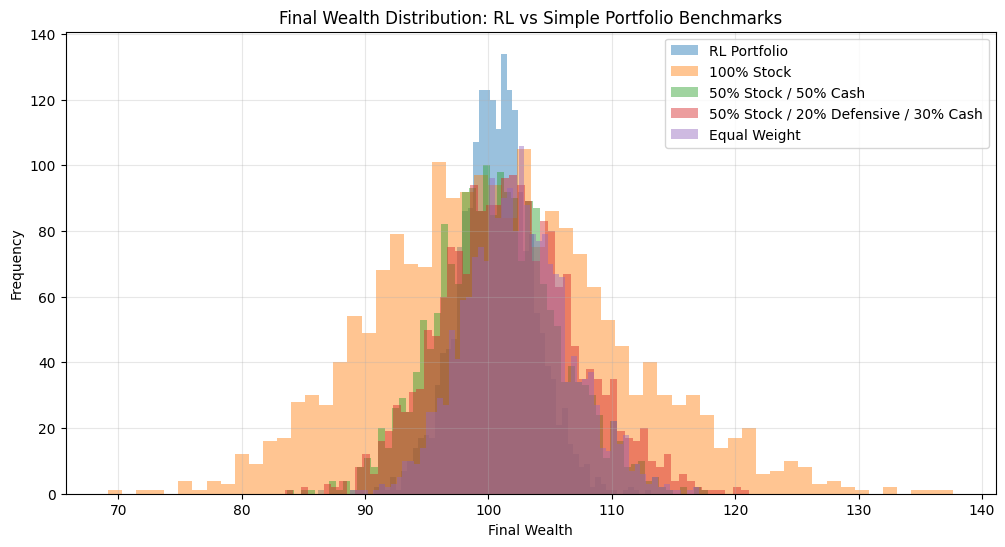

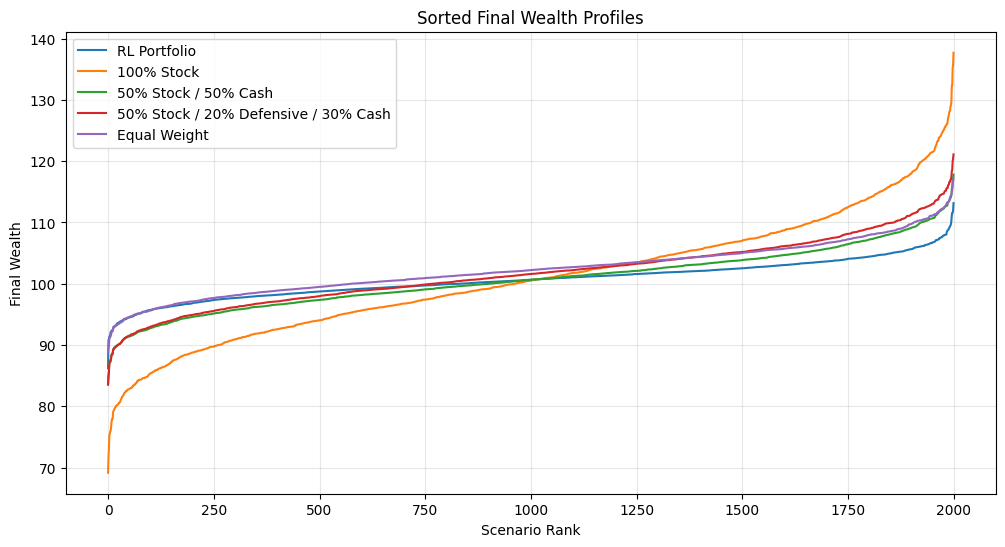

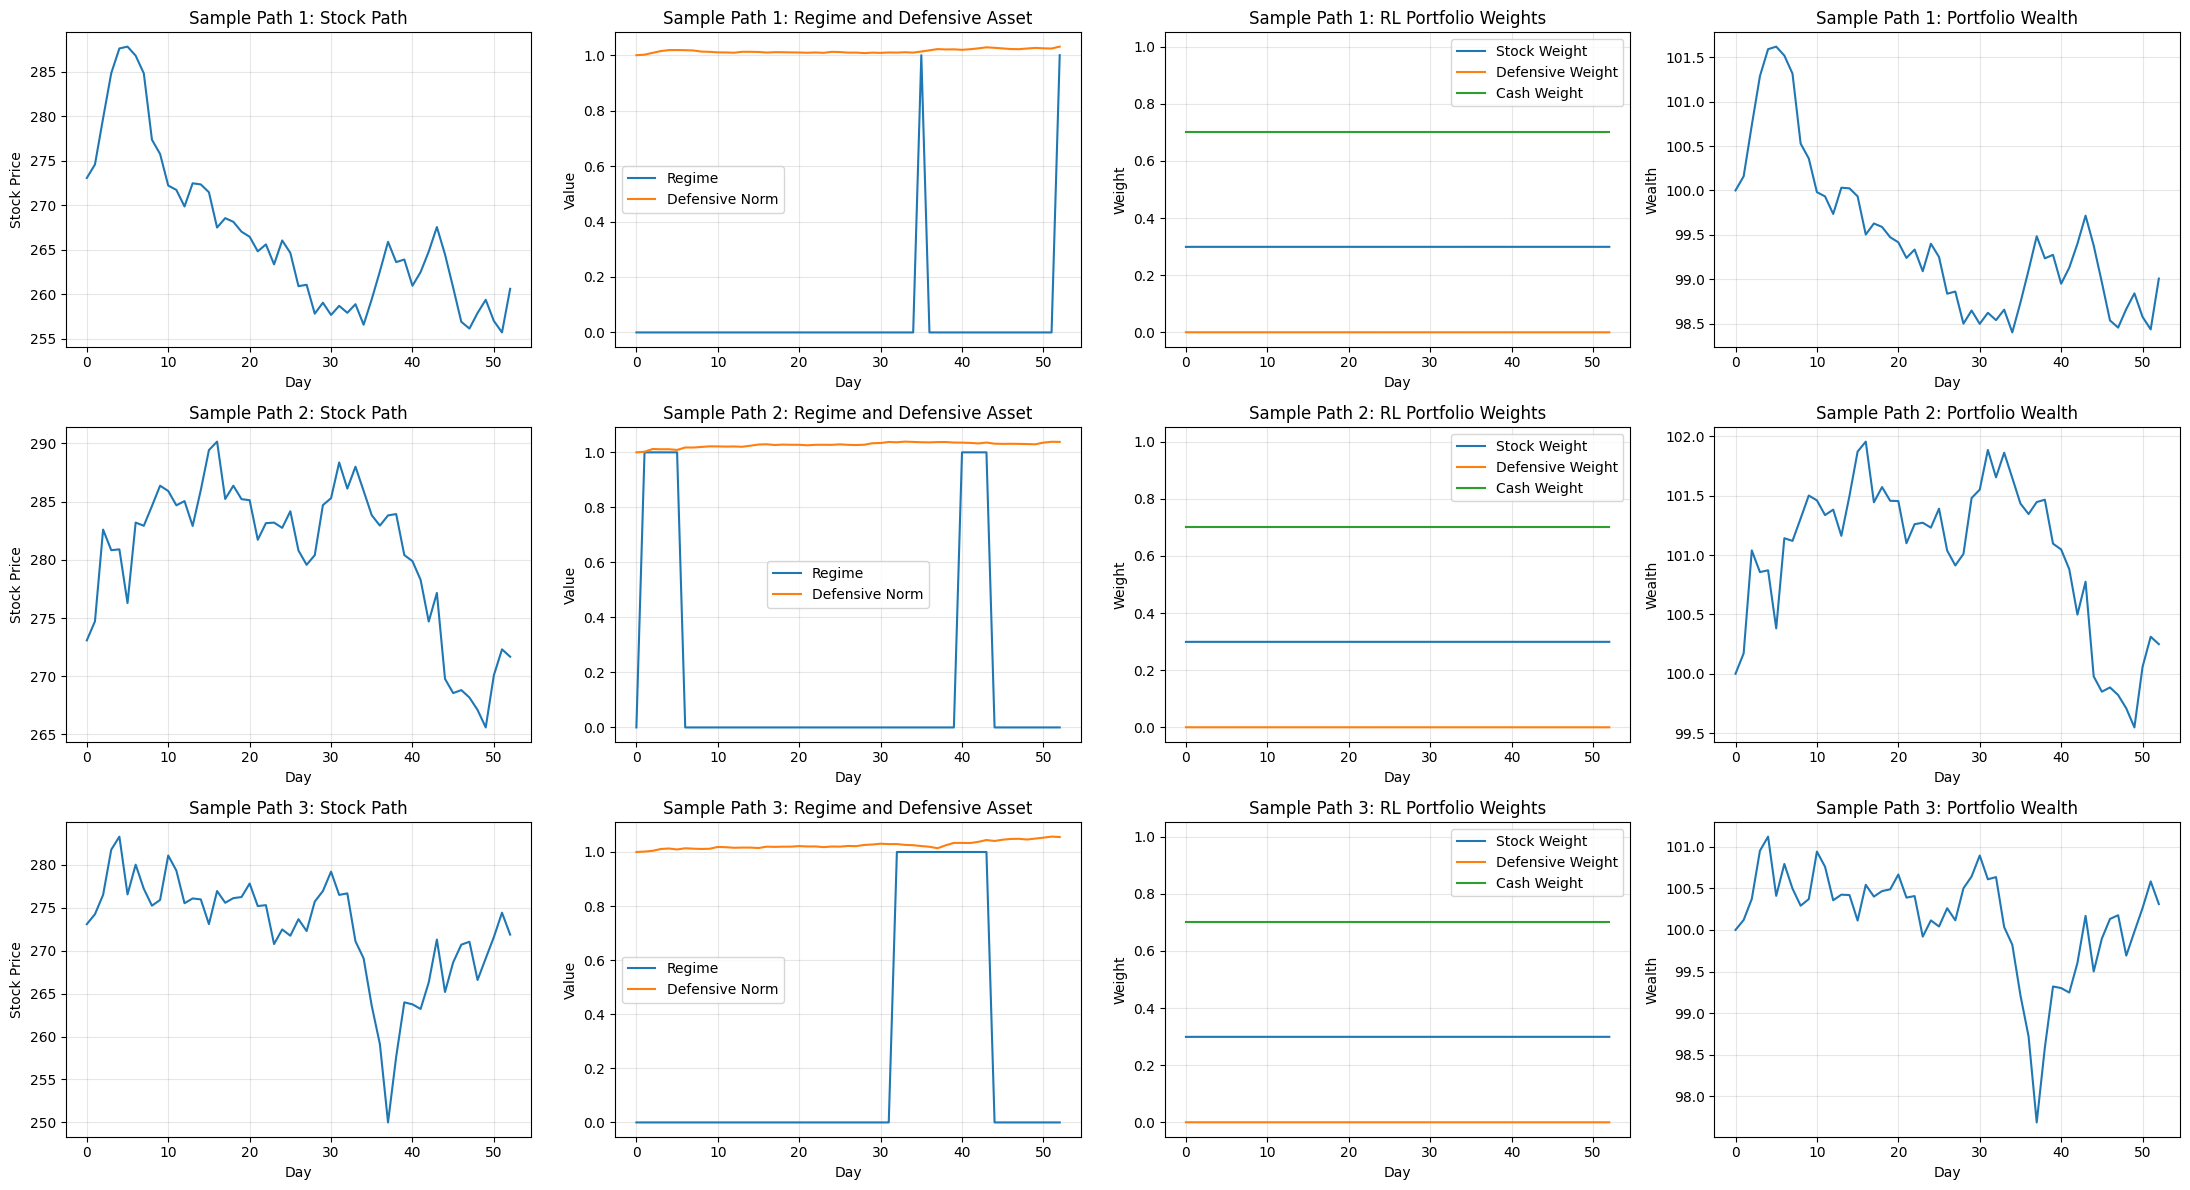

In [32]:
# ============================================================
# RL Portfolio Allocation with:
# - AAPL stock
# - defensive synthetic asset
# - cash
# - regime-dependent drift and volatility
# - richer state
# - excess-return reward
# ============================================================

# ============================================================
# 1. Inputs
# ============================================================

S0 = 273.08
T_days = 52
n_steps = T_days
dt = 1 / 365
r = 0.03686

transaction_cost_bps = 5
seed_train = TRAIN_SEED
seed_test = TEST_SEED

initial_wealth = 100.0

# Regime-dependent stock dynamics
mu_low = 0.12
mu_high = -0.08

sigma_low = 0.18
sigma_high = 0.40

# Reward / control
risk_penalty = 2.0
turnover_penalty = 0.03
weight_cap = 0.70


# ============================================================
# 2. Utility functions
# ============================================================

def capped_softmax_weights(x, cap=0.70):
    x = np.asarray(x, dtype=float)
    x = x - np.max(x)
    e = np.exp(x)
    w = e / np.sum(e)

    for _ in range(10):
        over = w > cap
        if not np.any(over):
            break

        excess = np.sum(w[over] - cap)
        w[over] = cap

        under = ~over
        if np.sum(under) == 0:
            break

        total_under = np.sum(w[under])
        if total_under > 1e-12:
            w[under] += excess * (w[under] / total_under)
        else:
            w[under] = excess / np.sum(under)

    w = np.maximum(w, 0.0)
    w = w / np.sum(w)
    return w


def compute_drawdown(path, t):
    peak = np.max(path[:t+1])
    if peak <= 1e-12:
        return 0.0
    return path[t] / peak - 1.0


# ============================================================
# 3. Regime-switching simulation
# ============================================================

def simulate_regime_path(n_steps, p_stay_low=0.94, p_stay_high=0.88, seed=123):
    """
    Regime 0 = favorable regime (lower vol, positive drift)
    Regime 1 = stressed regime (higher vol, negative drift)
    """
    regimes = np.zeros(n_steps + 1, dtype=int)
    rng = np.random.default_rng(seed)
    regimes[0] = 0

    for t in range(1, n_steps + 1):
        prev = regimes[t - 1]
        u = rng.random()

        if prev == 0:
            regimes[t] = 0 if u < p_stay_low else 1
        else:
            regimes[t] = 1 if u < p_stay_high else 0

    return regimes


def simulate_stock_path_with_regimes(S0, mu_low, mu_high, sigma_low, sigma_high, regimes, dt, seed=123):
    rng = np.random.default_rng(seed)
    n_steps = len(regimes) - 1
    Z = rng.standard_normal(n_steps)

    path = np.zeros(n_steps + 1, dtype=float)
    path[0] = S0

    for t in range(1, n_steps + 1):
        if regimes[t - 1] == 0:
            mu_t = mu_low
            sigma_t = sigma_low
        else:
            mu_t = mu_high
            sigma_t = sigma_high

        path[t] = path[t - 1] * np.exp(
            (mu_t - 0.5 * sigma_t**2) * dt + sigma_t * np.sqrt(dt) * Z[t - 1]
        )

    return path


def build_defensive_asset_from_stock(stock_path):
    """
    Build a stable defensive synthetic asset from the same AAPL path.
    - participates partially on upside
    - loses much less on downside
    """
    n_steps = len(stock_path) - 1
    defensive = np.zeros(n_steps + 1, dtype=float)
    defensive[0] = 100.0

    for t in range(n_steps):
        stock_ret = stock_path[t + 1] / stock_path[t] - 1.0

        if stock_ret >= 0:
            def_ret = 0.35 * stock_ret
        else:
            def_ret = 0.15 * stock_ret

        defensive[t + 1] = defensive[t] * (1.0 + def_ret)

    return defensive


# ============================================================
# 4. RL environment
# ============================================================

class PortfolioEnv(gym.Env):
    """
    RL portfolio allocation across:
    - stock
    - defensive synthetic asset
    - cash

    State:
        [
            stock_norm,
            defensive_norm,
            tau_frac,
            ret_1,
            mom_5,
            mom_10,
            drawdown,
            regime_flag,
            stock_weight,
            defensive_weight,
            cash_weight
        ]
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        S0,
        r,
        mu_low,
        mu_high,
        sigma_low,
        sigma_high,
        n_steps,
        dt,
        transaction_cost_bps=5,
        initial_wealth=100.0,
        risk_penalty=2.0,
        turnover_penalty=0.03,
        weight_cap=0.70,
        seed=42
    ):
        super().__init__()

        self.S0 = float(S0)
        self.r = float(r)
        self.mu_low = float(mu_low)
        self.mu_high = float(mu_high)
        self.sigma_low = float(sigma_low)
        self.sigma_high = float(sigma_high)
        self.n_steps = int(n_steps)
        self.dt = float(dt)
        self.transaction_cost_bps = float(transaction_cost_bps)
        self.initial_wealth = float(initial_wealth)
        self.risk_penalty = float(risk_penalty)
        self.turnover_penalty = float(turnover_penalty)
        self.weight_cap = float(weight_cap)

        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.action_space = spaces.Box(
            low=-5.0,
            high=5.0,
            shape=(3,),
            dtype=np.float32
        )

        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0, -1.0, -1.0, -1.0, -1.0, 0.0, 0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([10.0, 10.0, 1.0, 1.0, 5.0, 5.0, 0.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32
        )

        self.stock_path = None
        self.def_path = None
        self.regimes = None

        self.t = None
        self.wealth = None

        self.stock_units = None
        self.def_units = None
        self.cash = None

    def _simulate_paths(self):
        seed_regime = int(self.rng.integers(0, 1_000_000))
        seed_stock = int(self.rng.integers(0, 1_000_000))

        self.regimes = simulate_regime_path(
            n_steps=self.n_steps,
            p_stay_low=0.94,
            p_stay_high=0.88,
            seed=seed_regime
        )

        self.stock_path = simulate_stock_path_with_regimes(
            S0=self.S0,
            mu_low=self.mu_low,
            mu_high=self.mu_high,
            sigma_low=self.sigma_low,
            sigma_high=self.sigma_high,
            regimes=self.regimes,
            dt=self.dt,
            seed=seed_stock
        )

        self.def_path = build_defensive_asset_from_stock(self.stock_path)

    def _compute_weights(self, t):
        stock_value = self.stock_units * self.stock_path[t]
        def_value = self.def_units * self.def_path[t]
        cash_value = self.cash
        total = stock_value + def_value + cash_value

        if total <= 1e-12:
            return np.array([0.0, 0.0, 1.0])

        return np.array([
            stock_value / total,
            def_value / total,
            cash_value / total
        ])

    def _get_state(self):
        t = self.t

        stock_norm = self.stock_path[t] / self.S0
        def_norm = self.def_path[t] / self.def_path[0]
        tau_frac = (self.n_steps - t) / self.n_steps

        if t == 0:
            ret_1 = 0.0
            mom_5 = 0.0
            mom_10 = 0.0
        else:
            ret_1 = self.stock_path[t] / self.stock_path[t - 1] - 1.0
            t5 = max(0, t - 5)
            t10 = max(0, t - 10)
            mom_5 = self.stock_path[t] / self.stock_path[t5] - 1.0 if t5 < t else 0.0
            mom_10 = self.stock_path[t] / self.stock_path[t10] - 1.0 if t10 < t else 0.0

        drawdown = compute_drawdown(self.stock_path, t)
        w = self._compute_weights(t)

        state = np.array([
            stock_norm,
            def_norm,
            tau_frac,
            ret_1,
            mom_5,
            mom_10,
            drawdown,
            float(self.regimes[t]),
            w[0],
            w[1],
            w[2]
        ], dtype=np.float32)

        return state

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
    
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        else:
            self.rng = np.random.default_rng(self.seed)
    
        self._simulate_paths()

        self.t = 0
        self.wealth = self.initial_wealth

        self.stock_units = 0.0
        self.def_units = 0.0
        self.cash = self.initial_wealth

        return self._get_state(), {}

    def step(self, action):
        prev_wealth = (
            self.stock_units * self.stock_path[self.t]
            + self.def_units * self.def_path[self.t]
            + self.cash
        )
        prev_weights = self._compute_weights(self.t)

        target_weights = capped_softmax_weights(action, cap=self.weight_cap)

        stock_t = self.stock_path[self.t]
        def_t = self.def_path[self.t]

        target_stock_value = target_weights[0] * prev_wealth
        target_def_value = target_weights[1] * prev_wealth
        target_cash_value = target_weights[2] * prev_wealth

        target_stock_units = target_stock_value / stock_t
        target_def_units = target_def_value / def_t

        turnover_dollars = (
            abs(target_stock_units - self.stock_units) * stock_t
            + abs(target_def_units - self.def_units) * def_t
        )
        turnover_frac = turnover_dollars / max(prev_wealth, 1e-8)

        tc = turnover_dollars * (self.transaction_cost_bps / 10000.0)

        self.stock_units = target_stock_units
        self.def_units = target_def_units
        self.cash = max(target_cash_value - tc, 0.0)

        self.t += 1

        # accrue cash over step
        self.cash *= np.exp(self.r * self.dt)

        new_wealth = (
            self.stock_units * self.stock_path[self.t]
            + self.def_units * self.def_path[self.t]
            + self.cash
        )

        step_return = new_wealth / max(prev_wealth, 1e-8) - 1.0
        cash_step_return = np.exp(self.r * self.dt) - 1.0
        excess_return = step_return - cash_step_return

        reward = (
            excess_return
            - self.risk_penalty * (step_return ** 2)
            - self.turnover_penalty * turnover_frac
        )

        self.wealth = new_wealth

        terminated = self.t == self.n_steps
        truncated = False
        info = {"wealth": self.wealth}

        return self._get_state(), float(reward), terminated, truncated, info


# ============================================================
# 5. Train PPO
# ============================================================

def make_env():
    return PortfolioEnv(
        S0=S0,
        r=r,
        mu_low=mu_low,
        mu_high=mu_high,
        sigma_low=sigma_low,
        sigma_high=sigma_high,
        n_steps=n_steps,
        dt=dt,
        transaction_cost_bps=transaction_cost_bps,
        initial_wealth=initial_wealth,
        risk_penalty=risk_penalty,
        turnover_penalty=turnover_penalty,
        weight_cap=weight_cap,
        seed=seed_train
    )

vec_env = DummyVecEnv([make_env])
vec_env.seed(seed_train)

model = PPO(
    policy="MlpPolicy",
    env=vec_env,
    verbose=1,
    learning_rate=1e-4,
    n_steps=1024,
    batch_size=256,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.003,
    seed=seed_train
)

model.learn(total_timesteps=180000)


# ============================================================
# 6. Evaluation helpers
# ============================================================

def evaluate_rl_portfolio(model, n_eval_episodes=1000, seed=999):
    env = PortfolioEnv(
        S0=S0,
        r=r,
        mu_low=mu_low,
        mu_high=mu_high,
        sigma_low=sigma_low,
        sigma_high=sigma_high,
        n_steps=n_steps,
        dt=dt,
        transaction_cost_bps=transaction_cost_bps,
        initial_wealth=initial_wealth,
        risk_penalty=risk_penalty,
        turnover_penalty=turnover_penalty,
        weight_cap=weight_cap,
        seed=seed
    )

    final_wealths = []

    for i in range(n_eval_episodes):
        obs, _ = env.reset(seed=seed + i)
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        final_wealths.append(info["wealth"])

    return np.array(final_wealths, dtype=float)


def run_fixed_weight_path(weights, seed=123):
    seed_regime = seed
    seed_stock = seed + 1000

    regimes = simulate_regime_path(n_steps=n_steps, seed=seed_regime)
    stock_path = simulate_stock_path_with_regimes(
        S0=S0,
        mu_low=mu_low,
        mu_high=mu_high,
        sigma_low=sigma_low,
        sigma_high=sigma_high,
        regimes=regimes,
        dt=dt,
        seed=seed_stock
    )
    def_path = build_defensive_asset_from_stock(stock_path)

    wealth = initial_wealth
    stock_units = 0.0
    def_units = 0.0
    cash = wealth
    weights = np.array(weights, dtype=float)

    for t in range(n_steps):
        stock_t = stock_path[t]
        def_t = def_path[t]

        target_stock_value = weights[0] * wealth
        target_def_value = weights[1] * wealth
        target_cash_value = weights[2] * wealth

        stock_units = target_stock_value / stock_t
        def_units = target_def_value / def_t
        cash = target_cash_value

        cash *= np.exp(r * dt)

        wealth = (
            stock_units * stock_path[t + 1]
            + def_units * def_path[t + 1]
            + cash
        )

    return wealth


def evaluate_fixed_weight_benchmark(weights, n_eval_paths=1000, seed=123):
    wealths = []
    for i in range(n_eval_paths):
        wealths.append(run_fixed_weight_path(weights, seed=seed + i))
    return np.array(wealths, dtype=float)


# ============================================================
# 7. Evaluate RL and benchmarks
# ============================================================

wealth_rl = evaluate_rl_portfolio(model, n_eval_episodes=2000, seed=seed_test)

wealth_stock_only = evaluate_fixed_weight_benchmark([1.0, 0.0, 0.0], n_eval_paths=2000, seed=seed_test)
wealth_half_stock_cash = evaluate_fixed_weight_benchmark([0.5, 0.0, 0.5], n_eval_paths=2000, seed=seed_test)
wealth_stock_def_cash = evaluate_fixed_weight_benchmark([0.5, 0.2, 0.3], n_eval_paths=2000, seed=seed_test)
wealth_equal_weight = evaluate_fixed_weight_benchmark([1/3, 1/3, 1/3], n_eval_paths=2000, seed=seed_test)


# ============================================================
# 8. Summary table
# ============================================================

def summarize_wealth(name, wealth):
    returns = wealth / initial_wealth - 1.0
    return {
        "Strategy": name,
        "Mean Final Wealth": np.mean(wealth),
        "Median Final Wealth": np.median(wealth),
        "Std Final Wealth": np.std(wealth),
        "Mean Return": np.mean(returns),
        "1% Tail Wealth": np.percentile(wealth, 1),
        "5% Tail Wealth": np.percentile(wealth, 5),
        "Min Wealth": np.min(wealth),
        "Max Wealth": np.max(wealth)
    }

results = pd.DataFrame([
    summarize_wealth("RL Portfolio", wealth_rl),
    summarize_wealth("100% Stock", wealth_stock_only),
    summarize_wealth("50% Stock / 50% Cash", wealth_half_stock_cash),
    summarize_wealth("50% Stock / 20% Defensive / 30% Cash", wealth_stock_def_cash),
    summarize_wealth("Equal Weight", wealth_equal_weight)
])

print(results)


# ============================================================
# 9. Plots
# ============================================================

plt.figure(figsize=(12, 6))
plt.hist(wealth_rl, bins=60, alpha=0.45, label="RL Portfolio")
plt.hist(wealth_stock_only, bins=60, alpha=0.45, label="100% Stock")
plt.hist(wealth_half_stock_cash, bins=60, alpha=0.45, label="50% Stock / 50% Cash")
plt.hist(wealth_stock_def_cash, bins=60, alpha=0.45, label="50% Stock / 20% Defensive / 30% Cash")
plt.hist(wealth_equal_weight, bins=60, alpha=0.45, label="Equal Weight")
plt.title("Final Wealth Distribution: RL vs Simple Portfolio Benchmarks")
plt.xlabel("Final Wealth")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(np.sort(wealth_rl), label="RL Portfolio")
plt.plot(np.sort(wealth_stock_only), label="100% Stock")
plt.plot(np.sort(wealth_half_stock_cash), label="50% Stock / 50% Cash")
plt.plot(np.sort(wealth_stock_def_cash), label="50% Stock / 20% Defensive / 30% Cash")
plt.plot(np.sort(wealth_equal_weight), label="Equal Weight")
plt.title("Sorted Final Wealth Profiles")
plt.xlabel("Scenario Rank")
plt.ylabel("Final Wealth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# 10. Sample path diagnostics
# ============================================================

def get_rl_weight_path(model, seed=500):
    seed_regime = seed
    seed_stock = seed + 1000

    regimes = simulate_regime_path(n_steps=n_steps, seed=seed_regime)
    stock_path = simulate_stock_path_with_regimes(
        S0=S0,
        mu_low=mu_low,
        mu_high=mu_high,
        sigma_low=sigma_low,
        sigma_high=sigma_high,
        regimes=regimes,
        dt=dt,
        seed=seed_stock
    )
    def_path = build_defensive_asset_from_stock(stock_path)

    weights_hist = []
    wealth_hist = [initial_wealth]

    stock_units = 0.0
    def_units = 0.0
    cash = initial_wealth

    for t in range(n_steps + 1):
        wealth_t = stock_units * stock_path[t] + def_units * def_path[t] + cash
        wealth_t = max(wealth_t, 1e-8)

        stock_weight = (stock_units * stock_path[t]) / wealth_t
        def_weight = (def_units * def_path[t]) / wealth_t
        cash_weight = cash / wealth_t

        if t == 0:
            ret_1 = 0.0
            mom_5 = 0.0
            mom_10 = 0.0
        else:
            ret_1 = stock_path[t] / stock_path[t - 1] - 1.0
            t5 = max(0, t - 5)
            t10 = max(0, t - 10)
            mom_5 = stock_path[t] / stock_path[t5] - 1.0 if t5 < t else 0.0
            mom_10 = stock_path[t] / stock_path[t10] - 1.0 if t10 < t else 0.0

        drawdown = compute_drawdown(stock_path, t)
        tau_frac = (n_steps - t) / n_steps

        state = np.array([
            stock_path[t] / S0,
            def_path[t] / def_path[0],
            tau_frac,
            ret_1,
            mom_5,
            mom_10,
            drawdown,
            float(regimes[t]),
            stock_weight,
            def_weight,
            cash_weight
        ], dtype=np.float32)

        action, _ = model.predict(state, deterministic=True)
        target_weights = capped_softmax_weights(action, cap=weight_cap)
        weights_hist.append(target_weights.copy())

        if t < n_steps:
            target_stock_value = target_weights[0] * wealth_t
            target_def_value = target_weights[1] * wealth_t
            target_cash_value = target_weights[2] * wealth_t

            target_stock_units = target_stock_value / stock_path[t]
            target_def_units = target_def_value / def_path[t]

            turnover_dollars = (
                abs(target_stock_units - stock_units) * stock_path[t]
                + abs(target_def_units - def_units) * def_path[t]
            )
            tc = turnover_dollars * (transaction_cost_bps / 10000.0)

            stock_units = target_stock_units
            def_units = target_def_units
            cash = max(target_cash_value - tc, 0.0)
            cash *= np.exp(r * dt)

            wealth_next = (
                stock_units * stock_path[t + 1]
                + def_units * def_path[t + 1]
                + cash
            )
            wealth_hist.append(wealth_next)

    return stock_path, def_path, regimes, np.array(weights_hist), np.array(wealth_hist)


def plot_sample_portfolio_paths(model, n_sample_paths=3, base_seed=500):
    fig, axes = plt.subplots(n_sample_paths, 4, figsize=(22, 4 * n_sample_paths))
    if n_sample_paths == 1:
        axes = np.array([axes])

    for i in range(n_sample_paths):
        stock_path, def_path, regime_hist, weights_hist, wealth_hist = get_rl_weight_path(
            model=model,
            seed=base_seed + i
        )

        tgrid = np.arange(n_steps + 1)

        axes[i, 0].plot(tgrid, stock_path)
        axes[i, 0].set_title(f"Sample Path {i+1}: Stock Path")
        axes[i, 0].set_xlabel("Day")
        axes[i, 0].set_ylabel("Stock Price")
        axes[i, 0].grid(True, alpha=0.3)

        axes[i, 1].plot(tgrid, regime_hist, label="Regime")
        axes[i, 1].plot(tgrid, def_path / def_path[0], label="Defensive Norm")
        axes[i, 1].set_title(f"Sample Path {i+1}: Regime and Defensive Asset")
        axes[i, 1].set_xlabel("Day")
        axes[i, 1].set_ylabel("Value")
        axes[i, 1].grid(True, alpha=0.3)
        axes[i, 1].legend()

        axes[i, 2].plot(tgrid, weights_hist[:, 0], label="Stock Weight")
        axes[i, 2].plot(tgrid, weights_hist[:, 1], label="Defensive Weight")
        axes[i, 2].plot(tgrid, weights_hist[:, 2], label="Cash Weight")
        axes[i, 2].set_title(f"Sample Path {i+1}: RL Portfolio Weights")
        axes[i, 2].set_xlabel("Day")
        axes[i, 2].set_ylabel("Weight")
        axes[i, 2].set_ylim(-0.05, 1.05)
        axes[i, 2].grid(True, alpha=0.3)
        axes[i, 2].legend()

        axes[i, 3].plot(tgrid, wealth_hist)
        axes[i, 3].set_title(f"Sample Path {i+1}: Portfolio Wealth")
        axes[i, 3].set_xlabel("Day")
        axes[i, 3].set_ylabel("Wealth")
        axes[i, 3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_sample_portfolio_paths(model, n_sample_paths=3, base_seed=500)